# Modelling

This document follows the data cleaning and scraping by modelling the footfall data. The model is selected, tuned and fitted using the footfall data between 2019 and 2024. The model is then used later on to predict the 2025 footfall, to allow event evaluation.

The below steps are followed:

### 1) Model selection

The performance of four different machine learning models is tested using 10-fold cross validation. The models include:

* Linear regression
* Random Forest
* XGBoost
* Extra Trees Regressor

The outputs of the 10-fold cross validation process are used to calculate the error metric scores associated with that model (averaged over all folds). The MAE, the MAPE, the R2 and the RMSE metrics are compared to find the model that will best fit the data.

**Conclusion:** Random Forest Regression is the best performing model. After going through model selection **and** conducting model evaluation.

### 2) Model Evaluation

The performance of the model is tested, using a 80-20 test split with the chronological order of the data preserved. The model performance is evaluated using the error metrics of MAE, MAPE, R2 and RMSE.

### 3) Hyperparameter Tuning


Hyperparameter tuning is performed as it allows to find the best set of hyperparameters to maximise the model's efficiency and accuracy. 

### 4) Fitting the Final Model

Using the optimal hyperparameters found during the tuning, the model is fitted again, this time using the whole dataset (no training and test splits).

### 5) Feature Importance

The feature importance of the model predictor variables is investigated.

### 6) Using Model to Evaluate Events (Recursive Forecasting)

The final model is used to quantify the change in footfall that would otherwise been predicted in 2025.

In [294]:
pip install matplotlib geopandas numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [295]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

Here the data used to train and evaluate the models only contains the footfall data from 2019 to 2024.

In [296]:
#Load training footfall (2019-2024) data
data = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Bradford Analysis\footfall_cleaned_19_24")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2188 entries, 0 to 2187
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         2188 non-null   int64  
 1   datestamp                          2188 non-null   object 
 2   estimated_actual_footfall          2188 non-null   float64
 3   estimated_actual_footfall_rolling  2188 non-null   int64  
 4   year                               2188 non-null   int64  
 5   month                              2188 non-null   int64  
 6   monthday                           2188 non-null   int64  
 7   weekday                            2188 non-null   int64  
 8   week_of_year                       2188 non-null   int64  
 9   Sin_weekday                        2188 non-null   float64
 10  Cos_weekday                        2188 non-null   float64
 11  Sin_monthday                       2188 non-null   float

In [297]:
data.head()

,Unnamed: 0,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,...,Sin_month,Cos_month,is_weekend,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration
0,0,2019-01-01,530996.0,571980,2019,1,1,1,1,8.660254e-01,...,0.5,0.866025,0,1,1,0,6.470333,0.0,24.490587,27067.838
1,1,2019-01-02,568621.0,572734,2019,1,2,2,1,8.660254e-01,...,0.5,0.866025,0,0,1,0,2.616167,0.0,10.086427,27147.844
2,2,2019-01-03,606939.0,538667,2019,1,3,3,1,1.224647e-16,...,0.5,0.866025,0,0,1,0,0.699500,0.0,6.479999,27235.123
3,3,2019-01-04,508695.0,532787,2019,1,4,4,1,-8.660254e-01,...,0.5,0.866025,0,0,1,0,2.376583,0.0,15.629971,27329.416
4,4,2019-01-05,468546.0,507700,2019,1,5,5,1,-8.660254e-01,...,0.5,0.866025,1,0,0,0,4.080750,0.0,14.168641,27430.486


In [298]:
#Drop columns that are not variables used in the analysis
data.drop(['Unnamed: 0', 'month', 'weekday', 'week_of_year', 'monthday', 'datestamp'], axis=1, inplace=True)
data.head()

,estimated_actual_footfall,estimated_actual_footfall_rolling,year,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,is_weekend,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration
0,530996.0,571980,2019,8.660254e-01,0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025,0,1,1,0,6.470333,0.0,24.490587,27067.838
1,568621.0,572734,2019,8.660254e-01,-0.5,0.394356,0.918958,0.118273,0.992981,0.5,0.866025,0,0,1,0,2.616167,0.0,10.086427,27147.844
2,606939.0,538667,2019,1.224647e-16,-1.0,0.571268,0.820763,0.118273,0.992981,0.5,0.866025,0,0,1,0,0.699500,0.0,6.479999,27235.123
3,508695.0,532787,2019,-8.660254e-01,-0.5,0.724793,0.688967,0.118273,0.992981,0.5,0.866025,0,0,1,0,2.376583,0.0,15.629971,27329.416
4,468546.0,507700,2019,-8.660254e-01,0.5,0.848644,0.528964,0.118273,0.992981,0.5,0.866025,1,0,0,0,4.080750,0.0,14.168641,27430.486


In [299]:
#Chek NAs and drop rows with no footfall information
data['estimated_actual_footfall'].isna().sum()
data = data.dropna(subset=['estimated_actual_footfall'])
data['estimated_actual_footfall'].isna().sum()

0

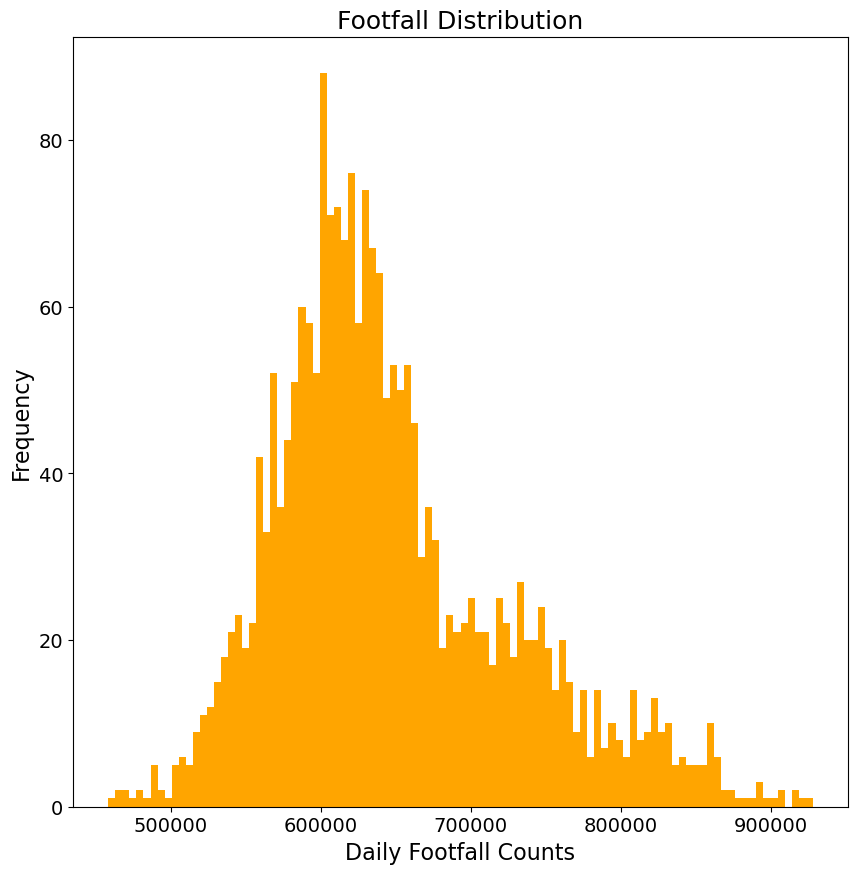

In [300]:
#Plot distribution of footfall counts
plt.figure(figsize=(10, 10))
plt.hist(data.estimated_actual_footfall, bins=100, color='orange')
plt.title('Footfall Distribution', fontsize=18)
plt.xlabel('Daily Footfall Counts', fontsize= 16)
plt.ylabel('Frequency', fontsize=16)
plt.tick_params(axis='both', labelsize= 14)
ax = plt.gca()  #get axes
ax.xaxis.get_offset_text().set_fontsize(14)
plt.show()

Explore relationship between variables.

In [301]:
#Scatter plots of relationship 
# between dependent variable (footfall counts) and contextual variables -> change x to investigate different predictor variables
#plt.figure(figsize=(10, 10))

#x = data['precipitation_sum'] # <- Change to different variables
#y = data['estimated_actual_footfall_rolling']

#Calculate fitted line
#z = np.polyfit(x, y, 1)
#trend = np.poly1d(z)

#Predicted y values
#y_pred = trend(x)

#Calculate R-Squared
#r = np.corrcoef(y,y_pred)[0,1]
#r2 = r**2

#Add percentage mean bias
#mean_bias = np.mean(y_pred - y)
#pmb = (mean_bias / np.mean(y)) * 100

#Plot points
#plt.scatter(x=x, y=y, color='blue', s=50, alpha=0.6)
#plt.xlabel("Precipitation", fontsize=20, weight='bold')
#plt.ylabel("Daily Footfall Counts", fontsize=20, weight='bold')

#Plot trend line and legend
#plt.plot(np.sort(x), trend(np.sort(x)), linewidth=3, color='red', linestyle='--', label=f'Trend: y = {z[0]:.3f}x + {z[1]:.3f} \n$R^2$ = {r2:.3f} \nPMB = {pmb:.3f}%')
#plt.legend(fontsize=18)

#plt.xticks(fontsize=14)
#plt.yticks(fontsize=14)
#Make the 1e-9 bigger at top of Y axis
#ax = plt.gca()  #get axes
#ax.yaxis.get_offset_text().set_fontsize(14)

#plt.title("")
#plt.show()

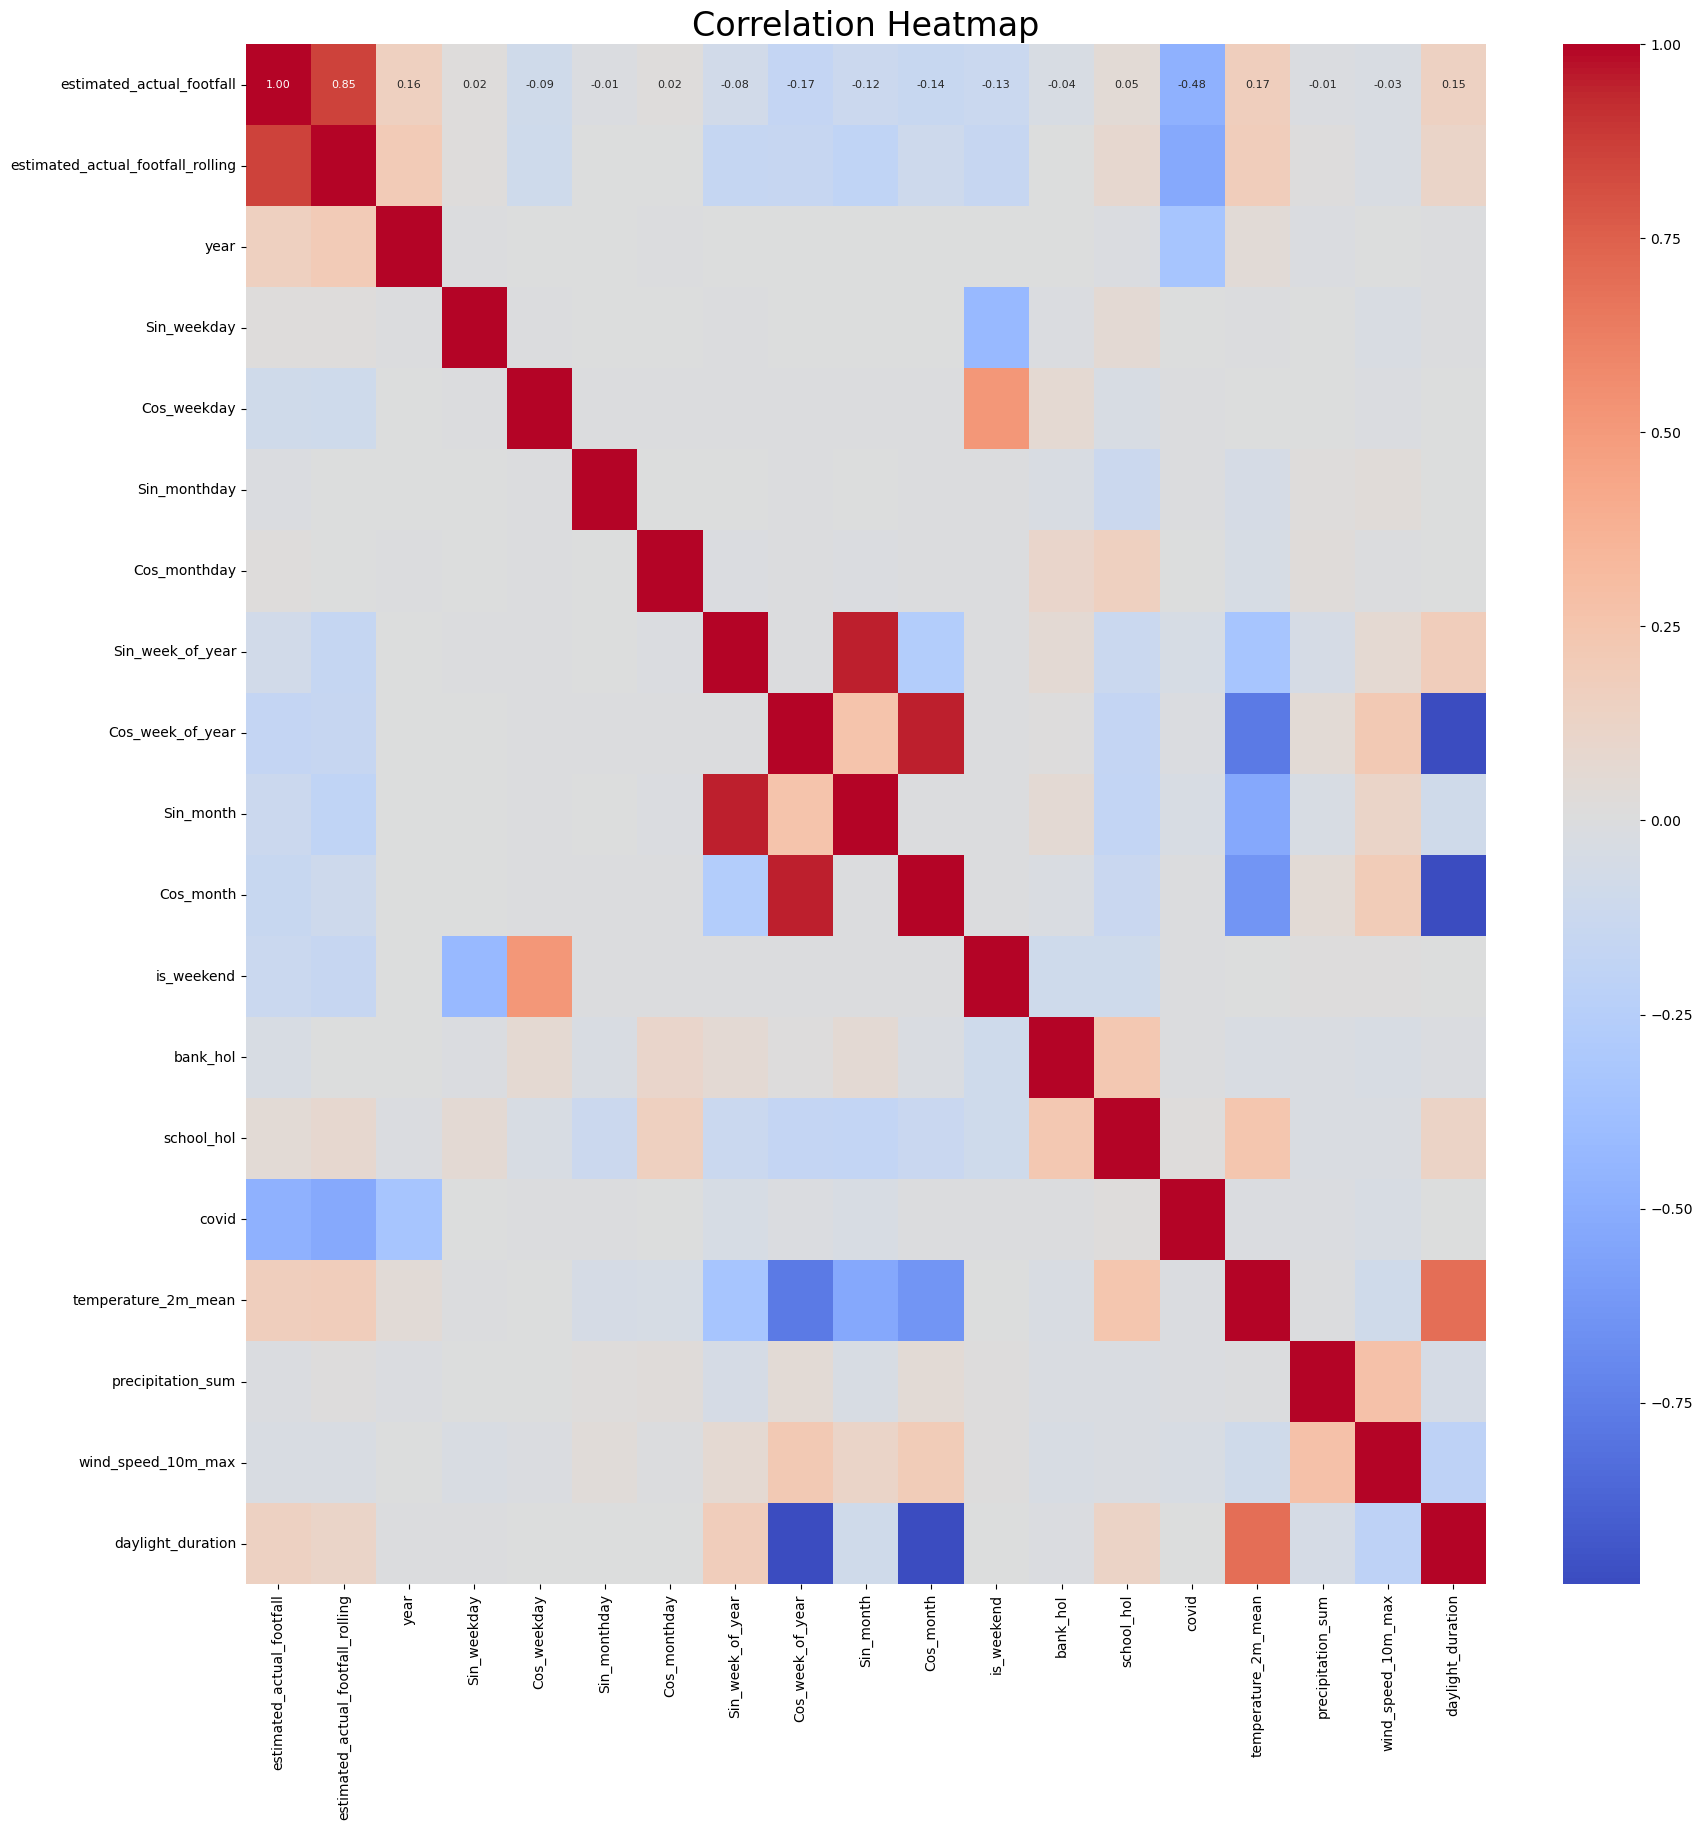

In [302]:
#Correlation Heatmap
plt.figure(figsize=(20, 20))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 8}, fmt=".2f")
plt.title('Correlation Heatmap', fontsize=24)
plt.show()

# 1- Model Selection

In [303]:
!pip install xgboost
!pip install scikit-learn==1.4.2

In [304]:
#Load packages
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
import xgboost as xgb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_validate
from time import time

In [305]:
#Prepare data for modelling

def prepare_x_y_data(input_data):
    data = input_data.copy()
    # Fill any missing values
    data = data.fillna(0)
    
    # Add a random variables (to compare performance of other variables against)
    #rng = np.random.RandomState(seed=42)
    #data['random'] = np.random.random(size=len(data)) #continuous random variable between 0 and 1
    #data["random_cat"] = rng.randint(3, size=data.shape[0]) #categorical random variable, integer is either 0, 1 or 2

    # Prepare data for modelling 
    # Split into predictor/predictand variables
    Xfull = data.drop(['estimated_actual_footfall'], axis =1) #Predictor variables
    Yfull = data['estimated_actual_footfall'].values #target variable

    return Xfull, Yfull

# Run function
Xfull, Yfull = prepare_x_y_data(data)

In [306]:
print("Running models with explanatory variables: ", Xfull.columns)

Running models with explanatory variables:  Index(['estimated_actual_footfall_rolling', 'year', 'Sin_weekday',
       'Cos_weekday', 'Sin_monthday', 'Cos_monthday', 'Sin_week_of_year',
       'Cos_week_of_year', 'Sin_month', 'Cos_month', 'is_weekend', 'bank_hol',
       'school_hol', 'covid', 'temperature_2m_mean', 'precipitation_sum',
       'wind_speed_10m_max', 'daylight_duration'],
      dtype='object')


Run the 4 models with cross-validation

Define the error metrics for the cross-validation to return, and the parameters of the cross validation


In [307]:
#Define error metrics
error_metrics = ['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']
#Split the data into 10 folds, shuffle=True ensures randomization
cv_parameters = KFold(n_splits=10, random_state=1, shuffle=True)

In [308]:
# Create dataframe to store the scores for all the models
error_metric_scores = pd.DataFrame()

In [309]:
#Create the 4 models
lr_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['linear_regressor',LinearRegression()]])
rf_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['rf_regressor', RandomForestRegressor(random_state = 1, n_jobs = 10)]])
xgb_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['xgb_regressor',xgb.XGBRegressor(random_state=1, n_jobs = 16)]])
et_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['et_regressor',ExtraTreesRegressor (random_state = 1, n_jobs = 16)]])

#Create dictionary to contain model results
models_dict = {"linear_regressor": lr_model_pipeline, 
               "xgb_regressor":xgb_model_pipeline,
               "rf_regressor":rf_model_pipeline,
               "et_regressor": et_model_pipeline}

In [310]:
# Run models with 10 fold cross validation

for model_name, model_pipeline in models_dict.items():
    print(model_name)
    # Use cross_validate to return the error scores associated with this model and this data
    start = time()
    model_output = cross_validate(model_pipeline, Xfull, Yfull, cv=cv_parameters, scoring=error_metrics, error_score="raise")

    end = time()
    print('Ran in {} minutes'.format(round((end - start)/60),2)) #how long model took to run
    
    # Formulate the different error scores into a dataframe
    error_metrics_df =pd.DataFrame({'mae': round(abs(model_output['test_neg_mean_absolute_error'].mean()),2), 
                  'mape': round(abs(model_output['test_neg_mean_absolute_percentage_error'].mean()),2),
                  'r2': round(abs(model_output['test_r2'].mean()),2), 
                  'rmse': round(abs(model_output['test_neg_root_mean_squared_error'].mean()),2)},
                 index =[model_name])
        
    # Add evaluation metric scores for this model to the dataframe containing the metrics for each model
    error_metric_scores = pd.concat([error_metric_scores, error_metrics_df])

linear_regressor
Ran in 0 minutes
xgb_regressor
Ran in 0 minutes
rf_regressor
Ran in 0 minutes
et_regressor
Ran in 0 minutes


In [311]:
#Check results
error_metric_scores.head()

,mae,mape,r2,rmse
linear_regressor,29705.30,0.05,0.74,40663.55
xgb_regressor,27005.49,0.04,0.79,36683.37
rf_regressor,26318.38,0.04,0.79,36348.50
et_regressor,24595.82,0.04,0.81,34140.93


**Results**:
* Mean Absolute Error: Extra Trees Regressor has the best accuracy (lowest mae)
* Mean Absolute Percentage Error: several models have the best accuracy (lowest mape)
* R-Squared: Extra Trees Regressor has the best accuracy (highest r2)
* Root Mean Squared Error: Extra Trees Regressor has the best accuracy (lowest rmse)

Conclusion: Extra Trees Regressor is the best performing model.

However, when running the below model evaluation, with 80/20 split of data by chronological order and TimeSeriesSplit in tuning, **the Random Forest Regressor outperforms the Extra Trees Regressor. Thus, Random Forest Regressor is chosen.**

# 2- Evaluating the Random Forest Regression model

the model needs to be fitted on all available data?

The first 80% of the data is used for training, and the last 20% for testing. Potential issues: the final portion of time might exhibit different patterns to the rest of the time.

As we are analysing time series data, we cannot choose random samples and assign them to either the test set or the train set because it doesn't make sense to use values from the future to forecast the past. There is a temporal dependency between observations, and this must be preserved during testing.

So, need to ensure that the test set always has a later time stamp than the training set.

In [312]:
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score, root_mean_squared_error

In [313]:
# Custom function for neg_mean_absolute_percentage_error
def neg_mean_absolute_percentage_error(y_true, y_pred):
    return -100 * np.mean(np.abs((y_true - y_pred) / y_true))

In [314]:
# Define the error metrics for the cross-validation to return
error_metrics = ['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']

In [315]:
# Set up model pipeline
rf_model_pipeline = Pipeline(steps=[['scaler',StandardScaler()],['rf_regressor', RandomForestRegressor(random_state = 1, n_jobs = 10)]])
model_dict = {"rf_regressor":rf_model_pipeline}

Get testing and training data

In [316]:
Xfull, Yfull = prepare_x_y_data(data)
dates = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Bradford Analysis\footfall_cleaned_19_24")['datestamp']

In [317]:
# Create train/test index lists based on a 80/20 split of data by chronological order
train_index = Xfull[0:int(len(Xfull)*0.8)].index.tolist()
test_index = Xfull[int(len(Xfull)*0.8):].index.tolist()

In [318]:
# Lists to store the error metric scores
mae_scores = []
rmse_scores= []
r2_scores= []
neg_mae_scores = []
# Lists to store predicted and actual values
predicted_values=[]
observed_values = []
# List to store the dates
dates_used = []

In [319]:
start = time()

# Get train and testing data for this fold
print(f"train index: {len(train_index)}")
print(f"test index: {len(test_index)}")
print(f"percentage of data used as testing: {round(len(test_index)/len(train_index)*100,1)}")

X_train, X_test = Xfull.iloc[train_index], Xfull.iloc[test_index]
y_train, y_test = Yfull[train_index], Yfull[test_index]

# Fit the model on the training data
rf_model_pipeline.fit(X_train, y_train)
# Use it to make predictions on the testing data, and store these
y_pred = rf_model_pipeline.predict(X_test)
predicted_values.append(y_pred)
# Store the datetimes
dates_used.append(dates[train_index])
# Store the actual values for the testing data
observed_values.append(y_test)
# Calculate the error metrics for this fold and append to the scores lists
mae_scores.append(mean_absolute_error(y_test, y_pred))
r2_scores.append(r2_score(y_test, y_pred))
rmse_scores.append(root_mean_squared_error(y_test, y_pred))
neg_mae_scores = [-score for score in mae_scores]        

end = time()
#Get time it took to run model in full
print('Ran cross_val_predict in {} minutes'.format(round((end - start)/60),2))

train index: 1750
test index: 438
percentage of data used as testing: 25.0
Ran cross_val_predict in 0 minutes


In [320]:
# Store lists of predicted and observed values
predicted_values_all = []
observed_values_all= []
for i in range(len(predicted_values)):
    for j in range(len(predicted_values[i])):
        observed_values_all.append(observed_values[i][j])
        predicted_values_all.append(predicted_values[i][j])

In [321]:
# Print evaluation metrics
print(f"Mean absolute error: {mae_scores}")
print(f"Mean R2: {r2_scores}")
print(f"Mean RMSE: {rmse_scores}")

Mean absolute error: [32700.723652968038]
Mean R2: [0.2465801096696263]
Mean RMSE: [42757.757443060356]


**Results:**
The Mean Absolute Error and Mean RMSE are quite high, indicating there is on average a difference of 66026.02 and 75400 footfall counts between predicted and observed values.The Mean R-Squared is negative, indicating the model does worse than using the average footfall for all predictions.

There is a need to tune the model's hyperparameters to improve the scores.

# 3- Hyperparameters Tuning with RandomizedSearchCV
Hyperparameter tuning allows to find the best set of hyperparameters to maximise the model's efficiency and accuracy. The Randomized Search exhaustively searches through all possible combinations of parameters provided in the param_grid.

The TimeSeriesSplit allows cross-validation for time series data, as future data should not be used to predict past data and random splits can cause data leakage. TimeSeriesSplit ensures that the training set comes before the test set.

As the model fitting is manually done here, the X values need to be scaled manually, whereas they were previously within the model pipeline.

In [322]:
# Define the error metrics for the cross-validation to return
error_metrics = ['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']

In [323]:
rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state= 1))])

In [324]:
#Create HyperParameter grid
param_grid = {
    'rf__n_estimators': [50, 100, 150, 200, 250, 300], #number of trees
    'rf__max_depth': [10, 20, 30, 40, None], #maximum depth of each tree
    'rf__min_samples_split': [2, 5, 10], #minimum n° of samples required to split a node
    'rf__min_samples_leaf': [1, 2, 4], #minimum samples at leaf node
    'rf__max_features': ['sqrt', 'log2', None], #n° of features to consider per split
    'rf__bootstrap': [True, False]
}

In [325]:
#Find the best hyperparameters settings for this model
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

#TimeSeriesSplit CV
#tscv= TimeSeriesSplit(n_splits= 10)

#rfr_Rsearch = RandomizedSearchCV(estimator= rf_model, 
                            param_distributions=param_grid, 
                            cv= tscv, 
                            verbose=2, 
                            n_iter=100, 
                            random_state=1,
                            n_jobs= 1,
                            scoring= 'neg_mean_absolute_error',
                            return_train_score= True
                            )
#rfr_Rsearch.fit(X_train, y_train)

#Display best hyperparameters
#print('Best hyperparameters:', rfr_Rsearch.best_params_)
#print('Best score', -rfr_Rsearch.best_score_)

IndentationError: unexpected indent (2491389725.py, line 8)

In [326]:
#Evaluate the holdout test set
#Make predictions
#y_pred = rfr_Rsearch.best_estimator_.predict(X_test)

#Use predictions to evaluate model
#mae = mean_absolute_error(y_test, y_pred)
#r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

# Print evaluation metrics
#print(f"Mean absolute error: {mae}")
#print(f"Mean R2: {r2}")
#print(f"Mean RMSE: {rmse}")

#R2 is increased to 30%

## Plot predicted vs actual values

In [327]:
pip install datashader

Note: you may need to restart the kernel to use updated packages.


In [328]:
import datashader as ds
from datashader.mpl_ext import dsshow

# Code from: https://stackoverflow.com/questions/20105364/how-can-i-make-a-scatter-plot-colored-by-density-in-matplotlib/53865762#53865762
def using_datashader(ax, x, y, normalisation):
    df = pd.DataFrame(dict(x=x, y=y))
    dsartist = dsshow(df,ds.Point("x", "y"),ds.count(), vmin=0.1, vmax=100,norm=normalisation,aspect="auto",ax=ax)
    cbar = plt.colorbar(dsartist, ax=ax)
    cbar.ax.tick_params(labelsize=10) 

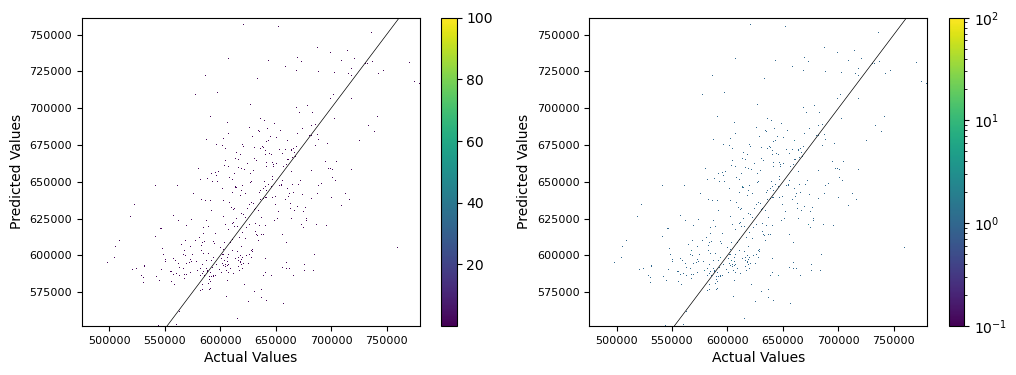

In [329]:
#Plot log and linear scales

import datashader as ds
from datashader.mpl_ext import dsshow
fig, axs = plt.subplots(ncols=2, figsize = (12,4))

# Plot with linear scale
using_datashader(axs[0], y_test, predicted_values_all, 'linear')
axs[0].plot([Yfull.min(), Yfull.max()], [Yfull.min(), Yfull.max()], c='k', lw=0.5)
axs[0].set_ylabel("Predicted Values", size=10)
axs[0].set_xlabel("Actual Values", size=10)
# axs[0].set_xlim([0, 2000])
# axs[0].set_ylim([0, 2000])
axs[0].tick_params(axis='both', which='major', labelsize=8)

# Plot with log scale
using_datashader(axs[1], y_test, predicted_values_all, 'log')
axs[1].plot([Yfull.min(), Yfull.max()], [Yfull.min(), Yfull.max()], c='k', lw=0.5)
axs[1].set_ylabel("Predicted Values", size=10)
axs[1].set_xlabel("Actual Values", size=10)
# axs[1].set_xlim([0, 2000])
# axs[1].set_ylim([0, 2000]);
axs[1].tick_params(axis='both', which='major', labelsize=8)

# 4- Fitting Final RFR Model

In [330]:
#Prepare data
Xfull, Yfull = prepare_x_y_data(data)

The final model is fitted, using all of the data (no train or test sets) and the optimal hyperparameters found with tuning.

In [331]:
# Fit the final model
rfr_pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators= 200,
                                  max_depth= None,
                                  min_samples_split= 10,
                                  min_samples_leaf = 4,
                                  max_features= None,
                                  random_state= 1,
                                  bootstrap= True))])

#Run the Random Forest Regressor, with the whole dataset
rfr_pipeline_final.fit(Xfull, Yfull)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(max_features=None, min_samples_leaf=4,
                                       min_samples_split=10, n_estimators=200,
                                       random_state=1))])

# 5- RFR Model Feature Importance

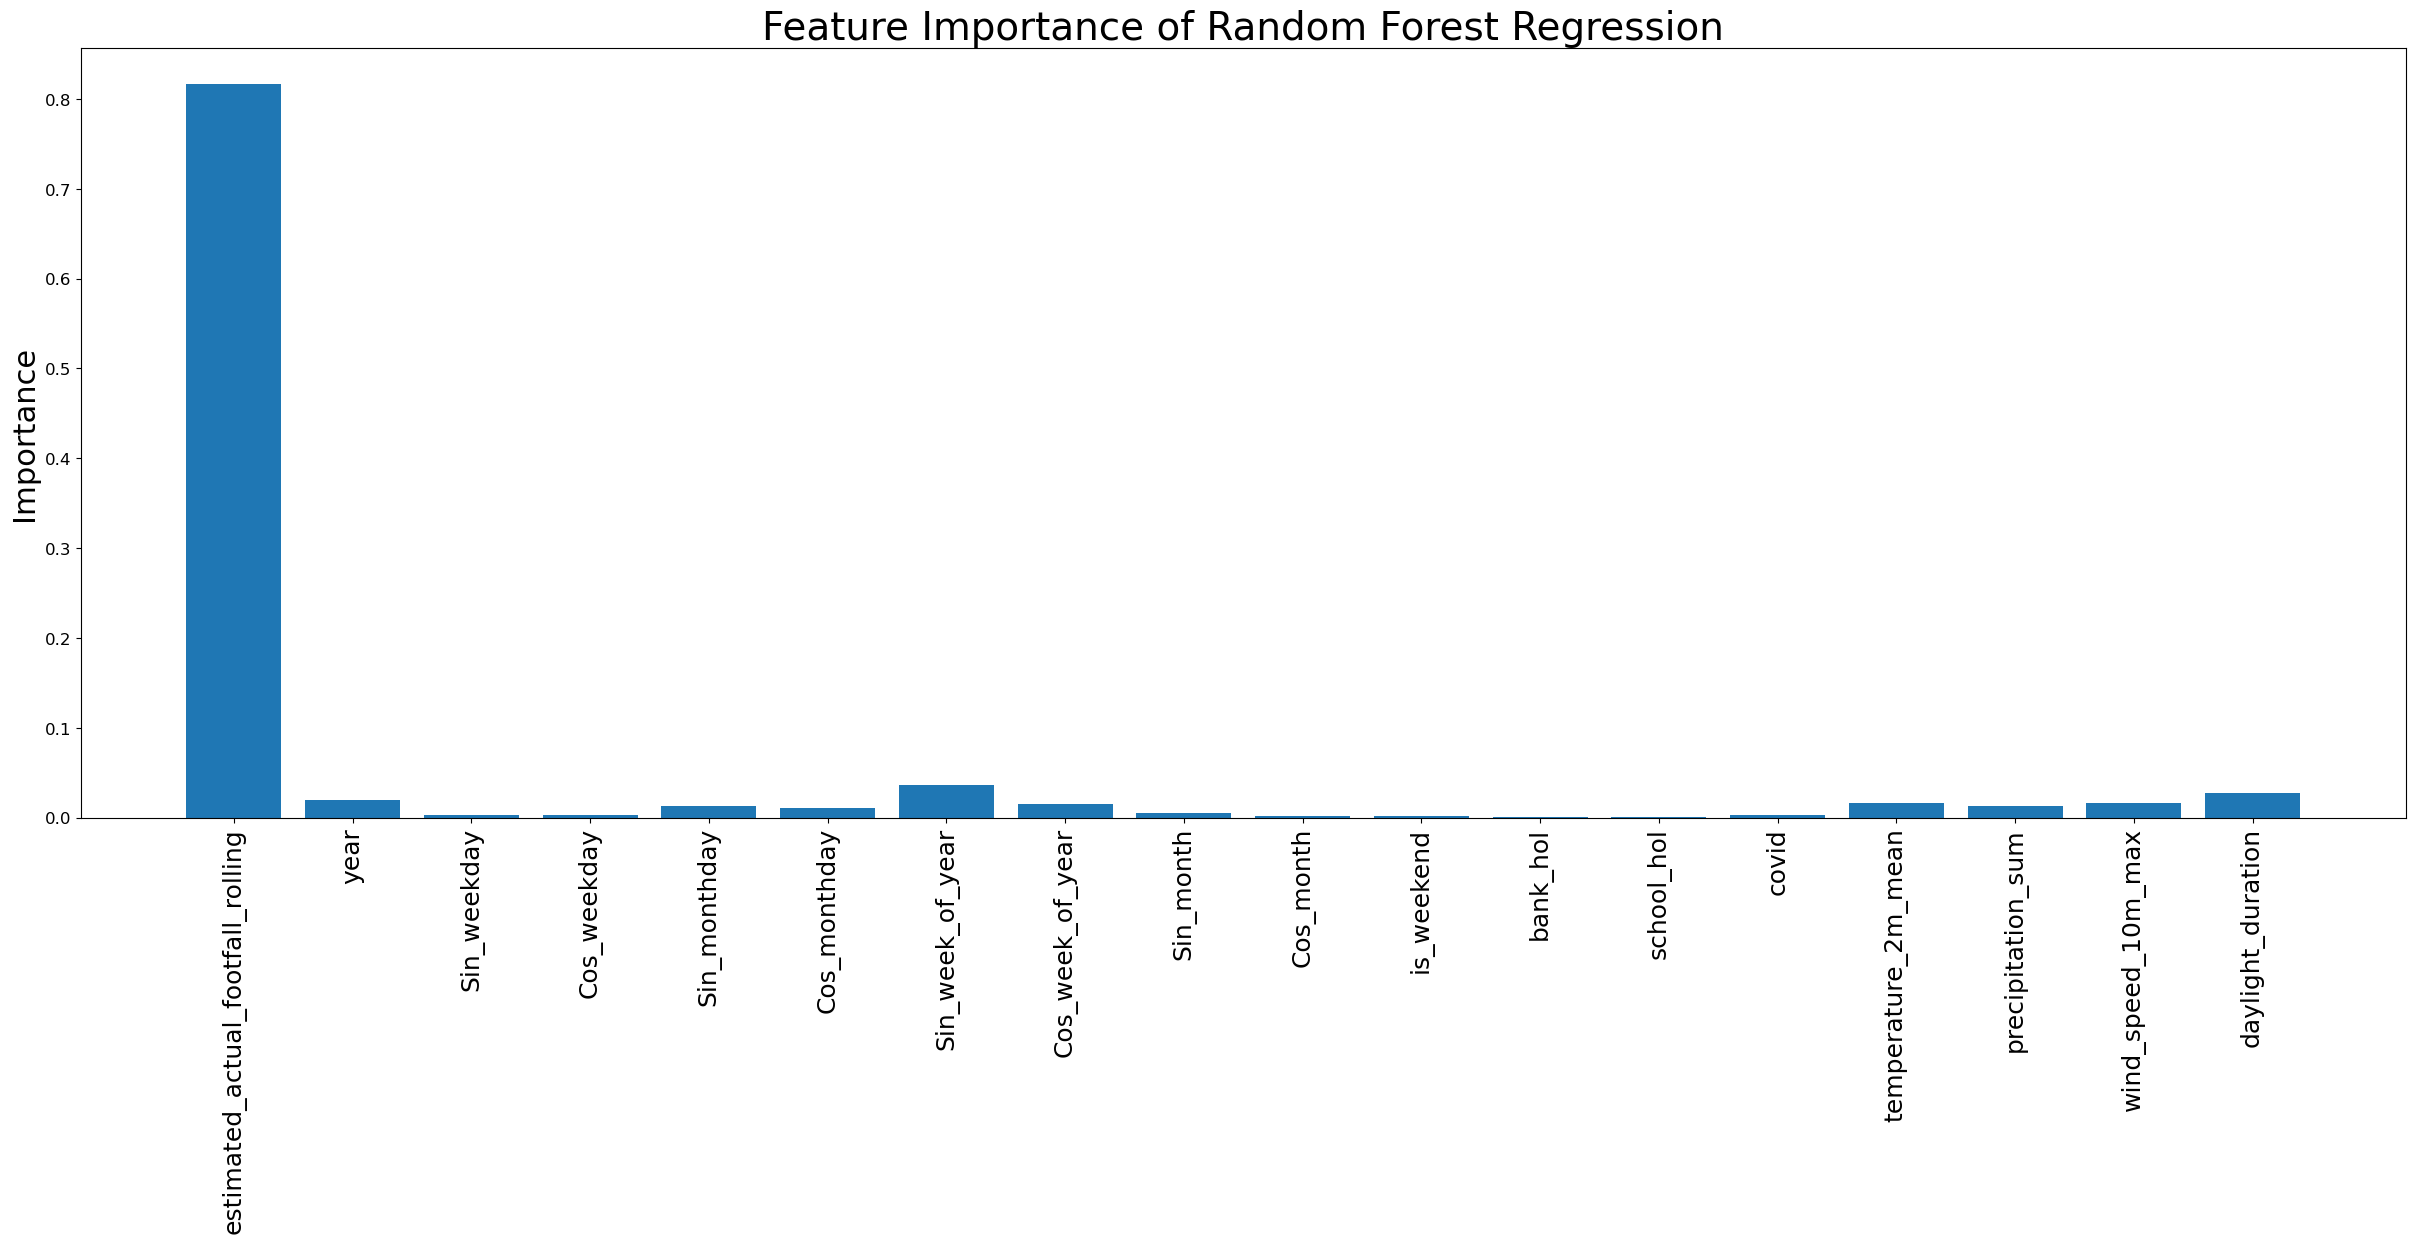

In [332]:
#Extract the rfr model from inside the pipeline
rf_model_final = rfr_pipeline_final.named_steps['rf']
#Extract feature importance from model
importance = rf_model_final.feature_importances_
#Extract feature names
features = Xfull.columns.tolist()

#Plot
plt.figure(figsize=(30, 10))
plt.bar(features, importance)
plt.title('Feature Importance of Random Forest Regression', fontsize= 28)
plt.ylabel('Importance', fontsize= 22)
plt.xticks(rotation=90, fontsize=18)
plt.yticks(size=12)
plt.show()

In [333]:
#Check feature importance values of model
for feat, imp in zip(Xfull.columns, importance):
    print(f"{feat}: {imp:.4f}")

estimated_actual_footfall_rolling: 0.8163
year: 0.0198
Sin_weekday: 0.0024
Cos_weekday: 0.0030
Sin_monthday: 0.0128
Cos_monthday: 0.0106
Sin_week_of_year: 0.0360
Cos_week_of_year: 0.0153
Sin_month: 0.0047
Cos_month: 0.0015
is_weekend: 0.0016
bank_hol: 0.0006
school_hol: 0.0011
covid: 0.0026
temperature_2m_mean: 0.0163
precipitation_sum: 0.0125
wind_speed_10m_max: 0.0158
daylight_duration: 0.0272


# 6- Using RFR model to evaluate events, with Recursive Forecasting

Now that the final Random Forest Regression has been trained on the footfall data between 2019 and 2024, the model is used to predict what footfall should have looked like in 2025 without any events, thus without the Bradford 2025 City of Culture program. Comparing the predicted vs the actual footfall values allows to access the success of the program by using footfall as a proxy.

A recursive forecasting technique is used. The Random Forest Regression model was trained using the rolling footfall as a feature. However, to keep the model blind to the fact that events were occuring, the 'estimated_actual_footfall_rolling' of the 2025 data is not fed into the model (only the contextual temporal and weather variables). Instead, the model uses the predicted footfall values from previous time steps as input, to calculate the rolling footfall itself.

In [334]:
#Load historical footfall (2019-2024) data again
data = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Bradford Analysis\footfall_cleaned_19_24")
#Drop columns that are not variables used in the analysis
data.drop(['Unnamed: 0', 'month', 'monthday', 'weekday', 'week_of_year'], axis=1, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2188 entries, 0 to 2187
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   datestamp                          2188 non-null   object 
 1   estimated_actual_footfall          2188 non-null   float64
 2   estimated_actual_footfall_rolling  2188 non-null   int64  
 3   year                               2188 non-null   int64  
 4   Sin_weekday                        2188 non-null   float64
 5   Cos_weekday                        2188 non-null   float64
 6   Sin_monthday                       2188 non-null   float64
 7   Cos_monthday                       2188 non-null   float64
 8   Sin_week_of_year                   2188 non-null   float64
 9   Cos_week_of_year                   2188 non-null   float64
 10  Sin_month                          2188 non-null   float64
 11  Cos_month                          2188 non-null   float

In [335]:
#Get data to make prediction on -> the 2025 footfall data
#Load training footfall (2019-2024) data
data_2025 = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Bradford Analysis\footfall_cleaned_2025")
data_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278 entries, 0 to 277
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         278 non-null    int64  
 1   datestamp                          278 non-null    object 
 2   estimated_actual_footfall          114 non-null    float64
 3   estimated_actual_footfall_rolling  278 non-null    int64  
 4   year                               278 non-null    int64  
 5   month                              278 non-null    int64  
 6   monthday                           278 non-null    int64  
 7   weekday                            278 non-null    int64  
 8   week_of_year                       278 non-null    int64  
 9   Sin_weekday                        278 non-null    float64
 10  Cos_weekday                        278 non-null    float64
 11  Sin_monthday                       278 non-null    float64

In [336]:
#Drop columns that are not variables used in the analysis
data_2025.drop(['Unnamed: 0', 'month', 'monthday', 'weekday', 'week_of_year'], axis=1, inplace=True)

#Drop rows with no estimated_actual_footfall (won't allow comparison with predicted values)
data_2025 = data_2025.dropna(subset=['estimated_actual_footfall'])

#Drop columns that are not supposed to be seen by the model
data_2025.drop(['estimated_actual_footfall_rolling'], axis=1, inplace=True)
data_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114 entries, 0 to 171
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   datestamp                  114 non-null    object 
 1   estimated_actual_footfall  114 non-null    float64
 2   year                       114 non-null    int64  
 3   Sin_weekday                114 non-null    float64
 4   Cos_weekday                114 non-null    float64
 5   Sin_monthday               114 non-null    float64
 6   Cos_monthday               114 non-null    float64
 7   Sin_week_of_year           114 non-null    float64
 8   Cos_week_of_year           114 non-null    float64
 9   Sin_month                  114 non-null    float64
 10  Cos_month                  114 non-null    float64
 11  is_weekend                 114 non-null    int64  
 12  bank_hol                   114 non-null    int64  
 13  school_hol                 114 non-null    int64  
 14 

In [337]:
#Prepare data for modelling
Xfull, Yfull = prepare_x_y_data(data_2025)

In [338]:
#Create function to calculate the estimated_actual_footfall_rolling
# for recursive forecasting

def calculate_estimated_rolling(df, date):
    weekday= date.weekday()
    #Filter all 6 past rows with same weekday
    past_same_weekday = df[df['datestamp'].dt.weekday == weekday].tail(6)

    #Not enough historical data
    if len(past_same_weekday) == 0:
        return None

    #Get average of previous 6 values for the day of the week
    else:
        return past_same_weekday['estimated_actual_footfall'].mean()

In [339]:
#Recursive forecasting function

"""
Recursive forecasting for future footfall

model: is the previously trained Random Forest Regressor model
history_df: is the data with historical data, used to previously train the model
future_df: is the data we want to predict the footfall for
            but excluding the rolling footfall
            including the 'datestamp' and 'estimated_actual_footfall' for comparison with model predictions
feature_cols: list of features used to train the model (excludes datestamp)

"""

def recursive_forecast(model, history_df, future_df, feature_cols):

    #Store footfall predictions
    predictions = []

    history = history_df.copy() #contains real past data + will contain predictions as loop runs

    for idx, row in future_df.iterrows():
        date = row['datestamp']

        #Calculate rolling footfall using historical + predicted footfall values
        rolling_value = calculate_estimated_rolling(history, date)

        #Add this rolling value to the row and prepare row for prediction
        row_copy = row.copy()
        row_copy['estimated_actual_footfall_rolling'] = rolling_value

        # Select only the features in the row used for modelling
        X_row = row_copy[feature_cols].to_frame().T

        #Use model to predict footfall
        y_pred = rf_model_final.predict(X_row.values)[0]
        predictions.append(y_pred)

        #Add this prediction into history for future rolling values
        new_history_row = row_copy.copy()
        new_history_row['estiamted_actual_footfall'] = y_pred
        history = pd.concat([history, pd.DataFrame([new_history_row])], ignore_index= True)

    #Add model predictions to the original future dataset
    future_df = future_df.copy()
    future_df['predicted_footfall'] = predictions
    return future_df

In [340]:
#Define the list of features used in model training
features = ['estimated_actual_footfall_rolling', 
            'year', 
            'Sin_weekday',
            'Cos_weekday', 
            'Sin_week_of_year', 
            'Cos_week_of_year',
            'Sin_monthday',
            'Cos_monthday',
            'Sin_month',
            'Cos_month', 
            'is_weekend', 
            'bank_hol',
            'school_hol', 
            'covid', 
            'temperature_2m_mean',
            'precipitation_sum', 
            'wind_speed_10m_max', 
            'daylight_duration']

In [341]:
#Ensure the datestamp columns of both datasets are datetime
data_2025['datestamp'] = pd.to_datetime(data_2025['datestamp'])
data['datestamp'] = pd.to_datetime(data['datestamp'])

In [342]:
#Call the recursive forecasting function
predictions_2025 = recursive_forecast(rf_model_final,
                                      data,
                                      data_2025,
                                      features)

predictions_2025.head()

,datestamp,estimated_actual_footfall,year,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,is_weekend,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration,predicted_footfall
0,2025-01-01,577601.0,2025,8.660254e-01,-0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025,0,1,1,0,5.499500,30.1,26.587042,27122.145,809782.646817
1,2025-01-02,607459.0,2025,1.224647e-16,-1.0,0.394356,0.918958,0.118273,0.992981,0.5,0.866025,0,0,1,0,-0.477583,0.0,13.379461,27203.908,808415.831663
2,2025-01-03,599189.0,2025,-8.660254e-01,-0.5,0.571268,0.820763,0.118273,0.992981,0.5,0.866025,0,0,1,0,1.820334,0.0,24.709875,27291.889,812837.314249
3,2025-01-04,624713.0,2025,-8.660254e-01,0.5,0.724793,0.688967,0.118273,0.992981,0.5,0.866025,1,0,0,0,0.953667,0.2,13.619471,27385.957,810785.996786
4,2025-01-05,553875.0,2025,-2.449294e-16,1.0,0.848644,0.528964,0.118273,0.992981,0.5,0.866025,1,0,0,0,0.680750,31.6,21.240000,27485.986,807353.983982


Visualize prediction vs actual footfall values in 2025. To do so calculate the percentage increase between the two.

In [343]:
#Calculate the percentage increase
predictions_2025['Percentage_Increase'] = ((predictions_2025['estimated_actual_footfall'] - predictions_2025['predicted_footfall']) / abs(predictions_2025['predicted_footfall'])) * 100

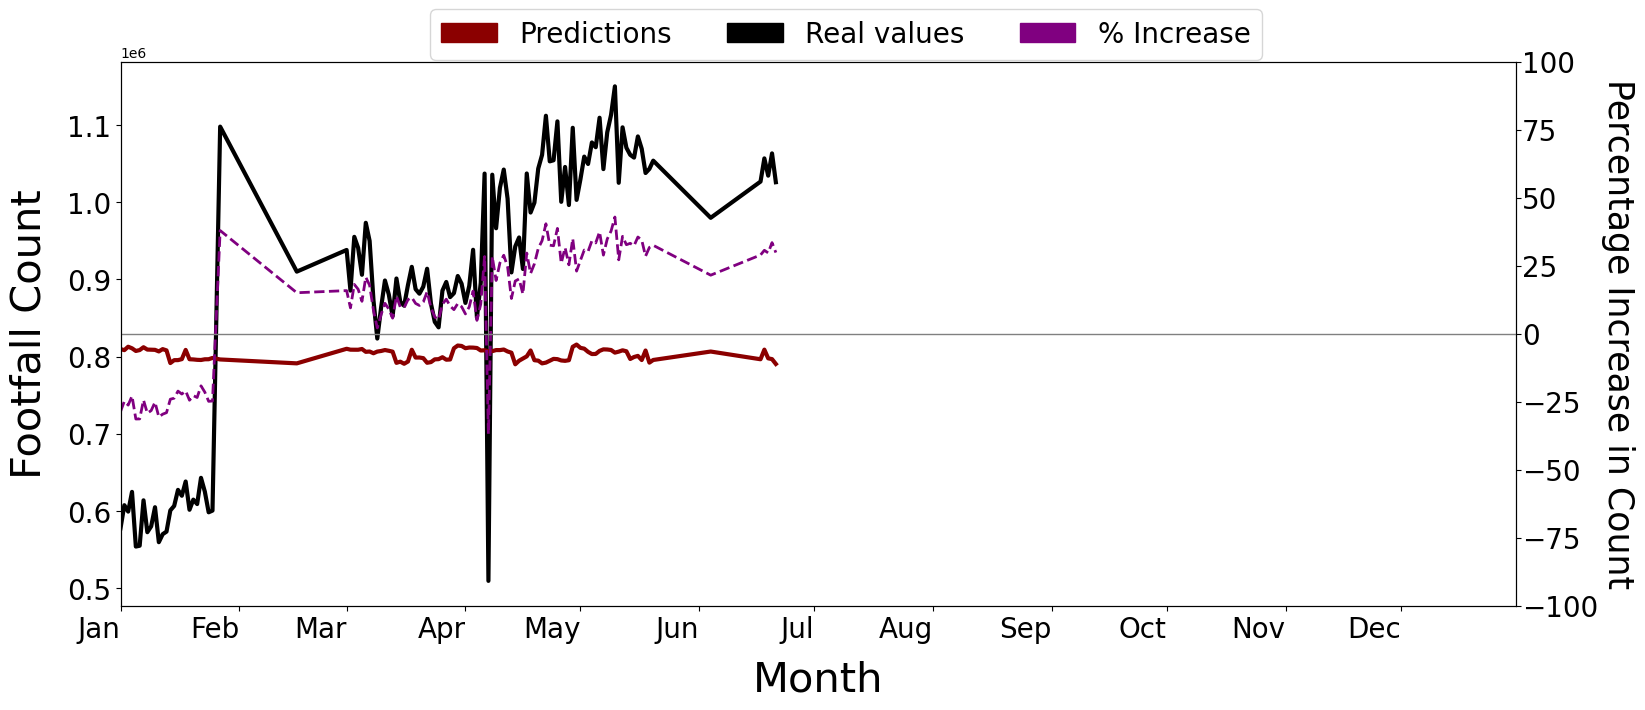

In [344]:
#Plot actual footfall, predicted footfall, and percentage increase between the two for comparison
import matplotlib.patches as mpatches
import matplotlib.dates as mdates


#Ensure datestamp is datetime
predictions_2025['datestamp'] = pd.to_datetime(predictions_2025['datestamp'])

include_percent_increase = True

fig, ax = plt.subplots(figsize = (18,8), sharex = True)

#Plot actual and predicted footfall
predictions_2025.plot(x='datestamp', y='estimated_actual_footfall', ax=ax, color='black', linewidth=3, legend =False)
predictions_2025.plot(x='datestamp', y='predicted_footfall', ax=ax, color='darkred', linewidth=3, legend =False)

#Plot percentage increase on secondary axis
if include_percent_increase==True:
    ax2 = ax.twinx()
    predictions_2025.plot(x='datestamp', y='Percentage_Increase', ax=ax2, color='purple', linewidth=2, legend =False, linestyle = 'dashed')
    ax2.set_ylabel('Percentage Increase in Count', fontsize=25, rotation=270, labelpad=27)
    ax2.tick_params(axis='both', which='major', labelsize=20, pad=1)
    ax2.set_ylim(-100,100)

#Set x axis to show month names, and tick parameters
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
#Force x axis to start in Jan and end in December
ax.set_xlim([pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31')])
ax.tick_params(axis='x', labelsize=20, rotation=0)
ax.tick_params(axis='y', labelsize=20)

#Set labels of axes
ax.set_xlabel('Month', fontsize = 30, labelpad=12)
ax.set_ylabel ('Footfall Count',fontsize=30, labelpad=12)

#Legend
colors_leg = ['darkred', 'black', 'purple']
texts = ['Predictions', 'Real values','% Increase'] 
patches = [ mpatches.Patch(color=colors_leg[i], label="{:s}".format(texts[i]) ) for i in range(len(texts)) ]    

plt.axhline(y = 0, color = 'grey', linestyle = '-', linewidth=1)     
plt.legend(handles=patches, bbox_to_anchor=(0.52, 1.05), loc='center', ncol=3, prop={'size': 20});

plt.show()

In [345]:
#Get yearly average of the %increase
predictions_2025.describe()

,datestamp,estimated_actual_footfall,year,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,...,is_weekend,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration,predicted_footfall,Percentage_Increase
count,114,1.140000e+02,114.0,1.140000e+02,114.000000,114.000000,114.000000,114.000000,114.000000,1.140000e+02,...,114.000000,114.000000,114.000000,114.0,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000
mean,2025-03-24 08:50:31.578947328,8.912255e+05,2025.0,1.266044e-17,0.140351,0.061805,-0.121825,0.729168,0.034597,7.091823e-01,...,0.289474,0.035088,0.131579,0.0,8.299463,1.290351,16.380429,45011.347570,802792.103114,11.038948
min,2025-01-01 00:00:00,5.093770e+05,2025.0,-8.660254e-01,-1.000000,-0.998717,-0.994869,0.118273,-0.984231,1.224647e-16,...,0.000000,0.000000,0.000000,0.0,-3.754667,0.000000,5.081613,27122.145000,790048.872486,-36.872829
25%,2025-03-02 06:00:00,8.464572e+05,2025.0,-8.660254e-01,-0.500000,-0.651372,-0.758758,0.456629,-0.507884,5.000000e-01,...,0.000000,0.000000,0.000000,0.0,4.762000,0.000000,12.063357,39324.400000,796340.897190,5.299653
50%,2025-03-30 12:00:00,9.137295e+05,2025.0,0.000000e+00,0.500000,0.151233,-0.250653,0.875735,-0.029581,8.660254e-01,...,0.000000,0.000000,0.000000,0.0,8.325541,0.000000,16.214989,46619.228500,806198.485747,14.788673
75%,2025-04-27 18:00:00,1.041287e+06,2025.0,8.660254e-01,1.000000,0.724793,0.528964,0.964636,0.456051,1.000000e+00,...,1.000000,0.000000,0.000000,0.0,10.824501,0.500000,18.862455,53695.311750,808762.399840,29.659361
max,2025-06-21 00:00:00,1.150276e+06,2025.0,8.660254e-01,1.000000,0.998717,1.000000,0.999561,0.992981,1.000000e+00,...,1.000000,1.000000,1.000000,0.0,23.001581,31.600000,36.900440,61567.870000,815647.384076,42.859856
std,NaN,1.786693e+05,0.0,6.618558e-01,0.742242,0.708190,0.698920,0.297677,0.618578,2.728883e-01,...,0.455520,0.184814,0.339525,0.0,5.234448,4.499065,5.761902,10600.240212,7057.795019,22.334874


So it seems like there was an 11% increase in footfall in 2025 compared to predictions.

In [346]:
#Get the monthly %increase averages to see which month were most affected by the Bradford25 events
monthly_2025 = predictions_2025.groupby(predictions_2025['datestamp'].dt.month)['Percentage_Increase'].mean()
monthly_2025

datestamp
1   -22.987080
2    15.024786
3    11.132769
4    22.049739
5    33.025826
6    28.992482
Name: Percentage_Increase, dtype: float64

So it seems like the month of May had the highest percentage increase with 33%. Whereas in January the footfall was lower than expected by -22%.